<a href="https://colab.research.google.com/github/Kenduiwo/kenduiwo/blob/main/Kiva_loan_analysis_in_Uganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

In [3]:
kiva=pd.read_csv('/content/drive/MyDrive/kiva_loans.csv')

In [65]:
loan_themes=pd.read_csv('/content/drive/MyDrive/loan_theme_ids.csv')

In [66]:
loan_themes.head(2)

,id,Loan Theme ID,Loan Theme Type,Partner ID
0,638631,a1050000000skGl,General,151.0
1,640322,a1050000000skGl,General,151.0


In [67]:
loan_themes_region=pd.read_csv('/content/drive/MyDrive/loan_themes_by_region.csv')

In [68]:
loan_themes_region.head(2)

,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,9,KREDIT Microfinance Institution,General Financial Inclusion,a1050000000slfi,Higher Education,Cambodia,No,Banteay Meanchey,"(13.75, 103.0)",KHM,...,450,"Banteay Meanchey, Cambodia","[(13.6672596, 102.8975098)]",Banteay Meanchey Province; Cambodia,"(13.6672596, 102.8975098)",13.667260,102.897510,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0
1,9,KREDIT Microfinance Institution,General Financial Inclusion,a10500000068jPe,Vulnerable Populations,Cambodia,No,Battambang Province,NaN,KHM,...,20275,"Battambang Province, Cambodia","[(13.0286971, 102.989615)]",Battambang Province; Cambodia,"(13.0286971, 102.989615)",13.028697,102.989615,"Banteay Mean Chey, Cambodia","(13.6672596, 102.8975098)",90.0


In [69]:
mpi_region=pd.read_csv('/content/drive/MyDrive/kiva_mpi_region_locations.csv')

In [70]:
mpi_region.head(2)

,LocationName,ISO,country,region,world_region,MPI,geo,lat,lon
0,"Badakhshan, Afghanistan",AFG,Afghanistan,Badakhshan,South Asia,0.387,"(36.7347725, 70.81199529999999)",36.734772,70.811995
1,"Badghis, Afghanistan",AFG,Afghanistan,Badghis,South Asia,0.466,"(35.1671339, 63.7695384)",35.167134,63.769538


In [4]:
kiva.shape

(671205, 20)

In [5]:
kiva.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01


In [6]:
kiva.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [7]:
kiva.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671205 entries, 0 to 671204
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  671205 non-null  int64  
 1   funded_amount       671205 non-null  float64
 2   loan_amount         671205 non-null  float64
 3   activity            671205 non-null  object 
 4   sector              671205 non-null  object 
 5   use                 666973 non-null  object 
 6   country_code        671197 non-null  object 
 7   country             671205 non-null  object 
 8   region              614405 non-null  object 
 9   currency            671205 non-null  object 
 10  partner_id          657698 non-null  float64
 11  posted_time         671205 non-null  object 
 12  disbursed_time      668809 non-null  object 
 13  funded_time         622874 non-null  object 
 14  term_in_months      671205 non-null  float64
 15  lender_count        671205 non-nul

In [12]:
top5_loan_countries=kiva["country"].value_counts().head(5).reset_index()

In [13]:
top5_loan_countries.columns=["country","loan_count"]

In [14]:
top5_loan_countries

,country,loan_count
0,Philippines,160441
1,Kenya,75825
2,El Salvador,39875
3,Cambodia,34836
4,Pakistan,26857


In [18]:
top5_loan_countries=kiva.groupby("country")["loan_amount"].sum().sort_values(ascending=False).head(5).reset_index()

In [19]:
top5_loan_countries.columns=["country","loan_amount"]

In [20]:
top5_loan_countries

,country,loan_amount
0,Philippines,55342225.0
1,Kenya,34534300.0
2,United States,31496375.0
3,Peru,30867400.0
4,Paraguay,29629075.0


#Choosing country Uganda for my analysis

In [22]:
kiva['country'].unique()

array(['Pakistan', 'India', 'Kenya', 'Nicaragua', 'El Salvador',
       'Tanzania', 'Philippines', 'Peru', 'Senegal', 'Cambodia',
       'Liberia', 'Vietnam', 'Iraq', 'Honduras', 'Palestine', 'Mongolia',
       'United States', 'Mali', 'Colombia', 'Tajikistan', 'Guatemala',
       'Ecuador', 'Bolivia', 'Yemen', 'Ghana', 'Sierra Leone', 'Haiti',
       'Chile', 'Jordan', 'Uganda', 'Burundi', 'Burkina Faso',
       'Timor-Leste', 'Indonesia', 'Georgia', 'Ukraine', 'Kosovo',
       'Albania', 'The Democratic Republic of the Congo', 'Costa Rica',
       'Somalia', 'Zimbabwe', 'Cameroon', 'Turkey', 'Azerbaijan',
       'Dominican Republic', 'Brazil', 'Mexico', 'Kyrgyzstan', 'Armenia',
       'Paraguay', 'Lebanon', 'Samoa', 'Israel', 'Rwanda', 'Zambia',
       'Nepal', 'Congo', 'Mozambique', 'South Africa', 'Togo', 'Benin',
       'Belize', 'Suriname', 'Thailand', 'Nigeria', 'Mauritania',
       'Vanuatu', 'Panama', 'Virgin Islands',
       'Saint Vincent and the Grenadines',
       "Lao Peo

In [23]:
uganda=kiva[kiva['country']=='Uganda']

In [24]:
uganda.head(2)

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
834,653954,100.0,100.0,Home Energy,Personal Use,to pay for a cooking gas package so that he ca...,UG,Uganda,Bulenga - Nankwandde,UGX,343.0,2014-01-05 22:16:53+00:00,2013-12-12 08:00:00+00:00,2014-01-08 00:29:31+00:00,9.0,4,NaN,male,irregular,2014-01-05
864,653953,100.0,100.0,Home Energy,Personal Use,to pay for a package of clean energy so that h...,UG,Uganda,Namulanda - Off Entebbe Road,UGX,343.0,2014-01-05 21:53:00+00:00,2013-12-23 08:00:00+00:00,2014-01-07 16:41:34+00:00,7.0,1,NaN,male,irregular,2014-01-05


In [25]:
uganda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20601 entries, 834 to 670553
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20601 non-null  int64  
 1   funded_amount       20601 non-null  float64
 2   loan_amount         20601 non-null  float64
 3   activity            20601 non-null  object 
 4   sector              20601 non-null  object 
 5   use                 20390 non-null  object 
 6   country_code        20601 non-null  object 
 7   country             20601 non-null  object 
 8   region              20390 non-null  object 
 9   currency            20601 non-null  object 
 10  partner_id          20601 non-null  float64
 11  posted_time         20601 non-null  object 
 12  disbursed_time      20601 non-null  object 
 13  funded_time         18249 non-null  object 
 14  term_in_months      20601 non-null  float64
 15  lender_count        20601 non-null  int64  
 16  tags  

In [26]:
uganda.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,211
country_code,0
country,0
region,211
currency,0


In [27]:
duplicates=uganda.duplicated().sum()

In [28]:
duplicates.sum()

0

#Dropping the null values from my uganda dataset

In [29]:
uganda.dropna(inplace=True)

In [30]:
uganda.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country_code,0
country,0
region,0
currency,0


In [31]:
uganda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12932 entries, 930 to 670520
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  12932 non-null  int64  
 1   funded_amount       12932 non-null  float64
 2   loan_amount         12932 non-null  float64
 3   activity            12932 non-null  object 
 4   sector              12932 non-null  object 
 5   use                 12932 non-null  object 
 6   country_code        12932 non-null  object 
 7   country             12932 non-null  object 
 8   region              12932 non-null  object 
 9   currency            12932 non-null  object 
 10  partner_id          12932 non-null  float64
 11  posted_time         12932 non-null  object 
 12  disbursed_time      12932 non-null  object 
 13  funded_time         12932 non-null  object 
 14  term_in_months      12932 non-null  float64
 15  lender_count        12932 non-null  int64  
 16  tags  

#Q1 total number of loans disbursed in uganda

In [32]:
uganda['id'].count()

12932

#Q2 total amount of loan disbursed in uganda

In [36]:
uganda['loan_amount'].sum()

10565625.0

#Q3 average loan amount disbursed in uganda

In [37]:
uganda['loan_amount'].mean()

817.0139962882771

#Loan distribution across different sectors

In [41]:
sector_loan_distributions=uganda['sector'].value_counts().sort_values(ascending=False).reset_index()

In [42]:
sector_loan_distributions.columns=["sector","loan_count"]

In [43]:
sector_loan_distributions

,sector,loan_count
0,Agriculture,3163
1,Food,2819
2,Retail,2286
3,Education,1453
4,Clothing,952
5,Housing,687
6,Services,632
7,Transportation,311
8,Construction,187
9,Health,174


#Summation of amount of loans distributed across different sectors

In [44]:
sector_loan_distributions=uganda.groupby('sector')['loan_amount'].sum().sort_values(ascending=False).reset_index()

In [45]:
sector_loan_distributions.columns=["sector","loan_amount"]

In [46]:
sector_loan_distributions

,sector,loan_amount
0,Agriculture,2572675.0
1,Food,2182600.0
2,Retail,1864925.0
3,Education,1539975.0
4,Clothing,619175.0
5,Housing,512300.0
6,Services,488450.0
7,Transportation,205775.0
8,Construction,173825.0
9,Health,168775.0


#Top 5 activities for which loans are disbursed in each sector

In [47]:
uganda.columns

Index(['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use',
       'country_code', 'country', 'region', 'currency', 'partner_id',
       'posted_time', 'disbursed_time', 'funded_time', 'term_in_months',
       'lender_count', 'tags', 'borrower_genders', 'repayment_interval',
       'date'],
      dtype='object')

In [50]:
top5_loan_activites=uganda['activity'].value_counts().head(5).sort_values(ascending=False).reset_index()

In [51]:
top5_loan_activites.columns=["activity","loan_count"]

In [52]:
top5_loan_activites

,activity,loan_count
0,Farming,1707
1,General Store,1167
2,Education provider,956
3,Personal Housing Expenses,529
4,Cattle,436


#Q6 How many unique partners are involved in loan disbursement and which partner is involved most

In [72]:
uganda_themes=loan_themes_region[loan_themes_region['country']=='Uganda'].reset_index(drop=True)

In [73]:
uganda_themes.head(2)

,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,65,BRAC Uganda,General Financial Inclusion,a1050000000wezZ,General,Uganda,No,Abaita Ababiri,NaN,UGA,...,1125,"Abaita Ababiri, Uganda","[(0.09353349999999999, 32.4990828)]",Abayita Ababiri; Lyamutundwe; Wakiso; Central ...,"(0.09353349999999999, 32.4990828)",0.093534,32.499083,"West Nile, Uganda","(0.3157239, 32.575568)",70.0
1,65,BRAC Uganda,General Financial Inclusion,a1050000000sg1c,Youth,Uganda,No,Abaita Ababiri,NaN,UGA,...,850,"Abaita Ababiri, Uganda","[(0.09353349999999999, 32.4990828)]",Abayita Ababiri; Lyamutundwe; Wakiso; Central ...,"(0.09353349999999999, 32.4990828)",0.093534,32.499083,"West Nile, Uganda","(0.3157239, 32.575568)",70.0


In [75]:
uganda_themes['Field Partner Name'].nunique()

15

In [76]:
uganda_themes['Field Partner Name'].mode()

,Field Partner Name
0,UGAFODE Microfinance


#Visualizing partners involved in loans disbursement

In [78]:
uganda_themes

,Partner ID,Field Partner Name,sector,Loan Theme ID,Loan Theme Type,country,forkiva,region,geocode_old,ISO,...,amount,LocationName,geocode,names,geo,lat,lon,mpi_region,mpi_geo,rural_pct
0,65,BRAC Uganda,General Financial Inclusion,a1050000000wezZ,General,Uganda,No,Abaita Ababiri,NaN,UGA,...,1125,"Abaita Ababiri, Uganda","[(0.09353349999999999, 32.4990828)]",Abayita Ababiri; Lyamutundwe; Wakiso; Central ...,"(0.09353349999999999, 32.4990828)",0.093534,32.499083,"West Nile, Uganda","(0.3157239, 32.575568)",70.0
1,65,BRAC Uganda,General Financial Inclusion,a1050000000sg1c,Youth,Uganda,No,Abaita Ababiri,NaN,UGA,...,850,"Abaita Ababiri, Uganda","[(0.09353349999999999, 32.4990828)]",Abayita Ababiri; Lyamutundwe; Wakiso; Central ...,"(0.09353349999999999, 32.4990828)",0.093534,32.499083,"West Nile, Uganda","(0.3157239, 32.575568)",70.0
2,65,BRAC Uganda,General Financial Inclusion,a1050000000wezZ,General,Uganda,No,Bowama,NaN,UGA,...,3925,"Bowama, Uganda","[(0.0642441, 32.1078868)]",Buwama; Mpigi; Central Region; Uganda,"(0.0642441, 32.1078868)",0.064244,32.107887,"East Central, Uganda","(0.2540775, 31.99280779999999)",70.0
3,65,BRAC Uganda,General Financial Inclusion,a1050000000wezZ,General,Uganda,No,Bugembe,"(0.4797222, 33.2344444)",UGA,...,750,"Bugembe, Uganda","[(0.465467, 33.2391334)]",Bugembe; Jinja; Eastern Region; Uganda,"(0.465467, 33.2391334)",0.465467,33.239133,"Central 2, Uganda","(0.3729261, 32.6357573)",70.0
4,65,BRAC Uganda,General Financial Inclusion,a1050000000sg1c,Youth,Uganda,No,Bugembe,"(0.4797222, 33.2344444)",UGA,...,425,"Bugembe, Uganda","[(0.465467, 33.2391334)]",Bugembe; Jinja; Eastern Region; Uganda,"(0.465467, 33.2391334)",0.465467,33.239133,"Central 2, Uganda","(0.3729261, 32.6357573)",70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,493,Jibu,Water and Sanitation,a1050000007z66Y,Clean Water Delivery,Uganda,No,Seeta,"(0.0, 31.9333333)",UGA,...,1750,"Seeta, Uganda","[(0.3669235, 32.7124903)]",Seeta; Mukono; Central Region; Uganda,"(0.3669235, 32.7124903)",0.366924,32.712490,"Central 2, Uganda","(0.3729261, 32.6357573)",NaN
300,495,"N/A, direct to Brent Oils",DSE Direct,a1050000007QS8Y,Equipment Purchase,Uganda,Yes,Kampala,"(0.3155556, 32.5655556)",UGA,...,20000,"Kampala, Uganda","[(0.3475964, 32.5825197)]",Kampala; Kampala; Central Region; Uganda,"(0.3475964, 32.5825197)",0.347596,32.582520,"Kampala, Uganda","(0.3475964, 32.5825197)",NaN
301,530,"N/A, direct to Jakana Foods",DSE Direct,a1050000008OYpb,SME,Uganda,No,Kampala,"(0.3155556, 32.5655556)",UGA,...,30000,"Kampala, Uganda","[(0.3475964, 32.5825197)]",Kampala; Kampala; Central Region; Uganda,"(0.3475964, 32.5825197)",0.347596,32.582520,"Kampala, Uganda","(0.3475964, 32.5825197)",NaN
302,532,"N/A, direct to All Across Africa",DSE Direct,a1050000008Oui7,SME,Uganda,No,Kampala,"(0.3155556, 32.5655556)",UGA,...,50000,"Kampala, Uganda","[(0.3475964, 32.5825197)]",Kampala; Kampala; Central Region; Uganda,"(0.3475964, 32.5825197)",0.347596,32.582520,"Kampala, Uganda","(0.3475964, 32.5825197)",NaN


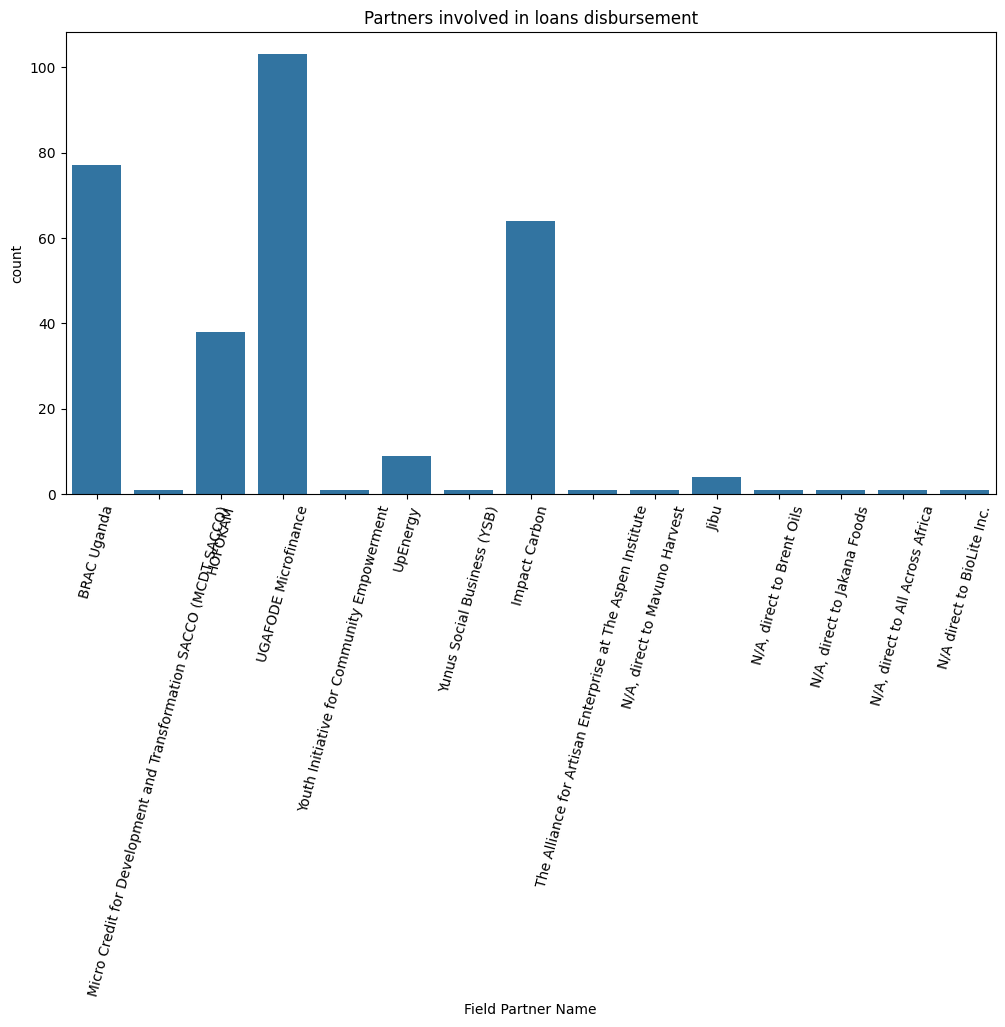

In [89]:
plt.figure(figsize=(12,6))
sns.countplot(x='Field Partner Name',data=uganda_themes)
plt.title("Partners involved in loans disbursement")
plt.xticks(rotation=75)
plt.show()

In [90]:
uganda_themes.columns

Index(['Partner ID', 'Field Partner Name', 'sector', 'Loan Theme ID',
       'Loan Theme Type', 'country', 'forkiva', 'region', 'geocode_old', 'ISO',
       'number', 'amount', 'LocationName', 'geocode', 'names', 'geo', 'lat',
       'lon', 'mpi_region', 'mpi_geo', 'rural_pct'],
      dtype='object')

In [91]:
frequent_field_partners=uganda_themes.groupby('Partner ID')['number'].count().sort_values(ascending=False).head(10).reset_index()

In [92]:
frequent_field_partners.columns=["partner_id","number"]

In [93]:
frequent_field_partners

,partner_id,number
0,222,103
1,65,77
2,329,64
3,163,38
4,290,9
5,493,4
6,112,1
7,287,1
8,315,1
9,412,1


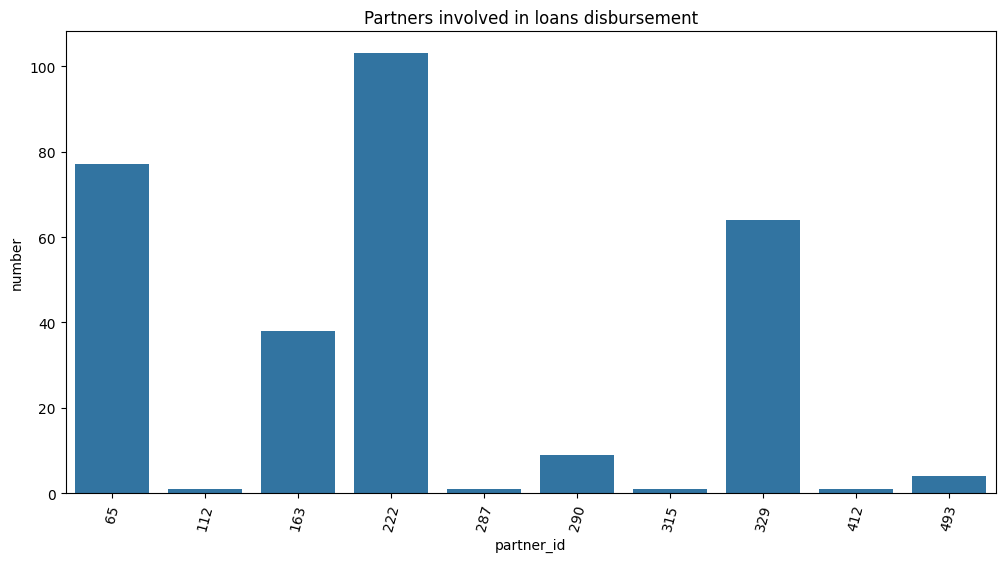

In [94]:
plt.figure(figsize=(12,6))
sns.barplot(x='partner_id',y='number',data=frequent_field_partners)
plt.title("Partners involved in loans disbursement")
plt.xticks(rotation=75)
plt.show()

In [101]:
partnernames_loans=uganda_themes.groupby('Field Partner Name')['amount'].sum().sort_values(ascending=False).reset_index()

In [102]:
partnernames_loans.head()

,Field Partner Name,amount
0,HOFOKAM,3401675
1,UGAFODE Microfinance,1887575
2,Impact Carbon,861800
3,BRAC Uganda,477650
4,Yunus Social Business (YSB),80000


In [103]:
fig=px.pie(partnernames_loans,values='amount',names='Field Partner Name',title='Partners involved in loans disbursement')
fig.show()